# 12 · Training options — text embeddings, architectures, the bake-off, parallel embedding

**Use case.** Same task as 02 (predict the rating), three ways to train it. Which options matter on this data, what they cost, and how to keep the best version serving.

**Model / lane:** GraphSAGE / GATv2 / GIN — the platform picks in max mode

**What you will learn**
1. v1 (from 02): the default — GraphSAGE with text embeddings
2. v2: `enable_text_embedding=False` — how much the review text is worth
3. v3: `max_mode=True` — the architecture bake-off (every architecture is trained, the best one ships)
4. `fan_out_workers`: what it parallelises and why it did not fire at this size
5. Compare the versions in one table, re-activate the best

**What this costs.** two more GPU runs on the regression project (the bake-off may launch several boxes; credits are estimated first and unused minutes refunded).

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
p = get_or_create_project(ls, "rating-regression", kind="data_science")
before = credits_used(ls)
versions = project_models(p)
v1 = next(m for m in sorted(versions, key=lambda m: m.get("version", 0)) if m.get("metrics"))
print("v1:", v1["label"], "· MAE", round(v1["metrics"]["mae"], 4))
print("text columns the task embeds:", json.loads(p.data["task_config"]).get("text_embed_columns") if isinstance(p.data.get("task_config"), str) else (p.data.get("task_config") or {}).get("text_embed_columns"))

reusing project 8847cd90-8444-4934-aad9-8faa372216bf (amazon-reviews-rating-regression, status=ready)


files already uploaded: ['customer.csv', 'product.csv', 'review.csv'] — skipping the upload
schema already detected — skipping
project ready: status=ready · type=data_science · files=['customer.csv', 'product.csv', 'review.csv']


v1: v1 · Baseline · MAE 0.4967
text columns the task embeds: {'review': ['review_text', 'summary'], 'product': ['description', 'title']}


## v2 · without text embeddings

`enable_text_embedding=False` keeps the text columns but encodes them categorically — the model sees the graph and the numbers, not the words. The estimate drops the embedding minutes; the metrics tell you what the words were worth.

In [3]:
from _common import wait_for_training, known_models
by_label = {m.get("display_name") or "": m for m in versions}
v2 = next((m for m in versions if m.get("metrics") and m.get("version") == 2), None)
if v2 is None:
    minutes = int(p.estimates()["train"]["suggested_minutes"]) + 2
    est = ls.credits.estimate_training(estimated_minutes=minutes, max_training_min=minutes, project_id=p.id)
    print("reservation for a normal run:", est["max_cost"], "credits for", minutes, "min")
    known = known_models(p)
    p.train(enable_text_embedding=False, max_training_min=minutes)
    v2 = wait_for_training(p, known_model_ids=known)
print("v2:", v2.get("version_label"), v2.get("model_type"), "· MAE", round(v2["metrics"]["mae"], 4), "·", v2.get("training_duration_sec"), "s")

v2: v2 Baseline · MAE 0.7299 · 30 s


## v3 · the bake-off (`max_mode=True`)

Max mode trains every architecture the plan allows — GraphSAGE small and full, GATv2, GIN — and keeps the single best on the validation metric. One model row comes back; `model_type` says who won. On Max/Team plans the platform can put each architecture on its own GPU box (`benchmark_workers` in the estimate says how many it will launch); when that is 0 the four run one after another on one box, which is what happened here.

In [4]:
v3 = next((m for m in project_models(p) if m.get("metrics") and m.get("version") == 3), None)
if v3 is None:
    minutes = int(p.estimates()["train"]["suggested_minutes"]) + 2
    est = ls.credits.estimate_training(estimated_minutes=minutes, max_training_min=minutes, project_id=p.id, max_mode=True)
    print("reservation in max mode:", est["max_cost"], "credits · benchmark workers:", est["benchmark_workers"])
    known = known_models(p)
    p.train(max_mode=True, enable_text_embedding=True, max_training_min=minutes)
    v3 = wait_for_training(p, known_model_ids=known)
print("v3:", v3.get("version_label"), "· winner:", v3.get("model_type"), "· MAE", round(v3["metrics"]["mae"], 4), "·", v3.get("training_duration_sec"), "s")

v3: v3 · winner: Baseline · MAE 0.476 · 152 s


## `fan_out_workers` — parallel text embedding

On Max/Team plans, `fan_out_workers=2` or `3` splits the *text embedding* step across helper boxes. It only fires when the embedding estimate is at least 5 minutes — 10,000 reviews × 4 text columns embed in about 3 minutes on one box, so here the platform runs single-box and says so. The estimate still shows the helper cost, which is how you decide.

In [5]:
rows = []
floor = int(p.estimates()["train"]["suggested_minutes"])
for kw in ({}, {"fan_out_workers": 2}, {"fan_out_workers": 3}, {"max_mode": True}):
    r = ls.credits.estimate_training(estimated_minutes=floor, max_training_min=floor, project_id=p.id, **kw)
    rows.append({"options": kw or "default", "reserved_credits": r["max_cost"], "fan_out_helpers": r["fan_out_helpers"], "benchmark_workers": r["benchmark_workers"]})
print("train floor for this project:", p.estimates()["train"])
pd.DataFrame(rows)

train floor for this project: {'instance_type': 'g4dn.2xlarge', 'suggested_minutes': 71, 'embed_minutes_estimate': 8, 'text_cols': 4, 'credits_route': '/api/v1/credits/estimate-training'}


,options,reserved_credits,fan_out_helpers,benchmark_workers
0,default,9443,0,0
1,{'fan_out_workers': 2},10931,1,0
2,{'fan_out_workers': 3},12419,2,0
3,{'max_mode': True},9443,0,0


## Compare and choose

Three versions, one table. Activate the best by MAE — `predict` with `active:<project>` then serves it without any client change.

,version,architecture,seconds,active
0,v1,Baseline,85,False
1,v2,Baseline,30,False
2,v3,Baseline,152,True


,v1,v2,v3
r2,0.4379,-0.0493,0.4816
mae,0.4967,0.7299,0.4760
rmse,0.6894,0.9420,0.6621
mae_zero,4.4630,4.4630,4.4630
spearman,0.5317,0.2527,0.5356
mae_median,0.5370,0.5370,0.5370
lift_at_1pct,1.1203,1.1203,1.1203
lift_at_5pct,1.1091,1.1203,1.1091
lift_at_10pct,1.1069,1.1192,1.1058
lift_at_0.1pct,1.1203,1.1203,1.1203


serving: v3 Baseline · MAE 0.476


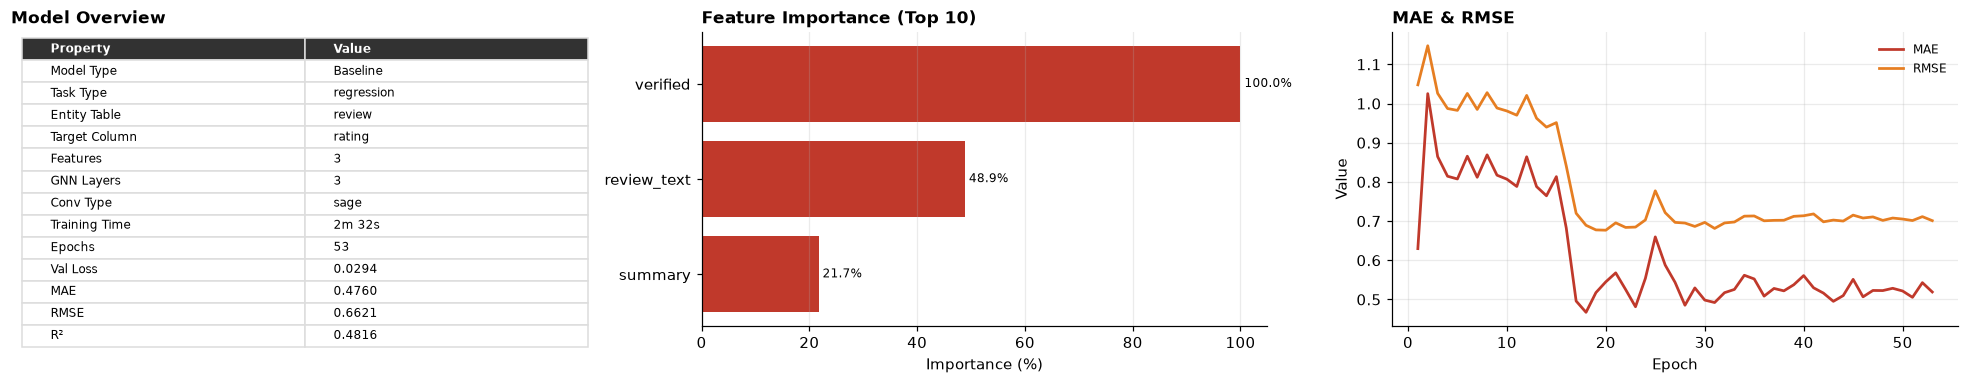

In [6]:
versions = sorted([m for m in p.models.list() if m.get("metrics")], key=lambda m: m.get("version", 0))
display(pd.DataFrame([{"version": m.get("version_label"), "architecture": m.get("model_type"), "seconds": m.get("training_duration_sec"), "active": m.get("is_active")} for m in versions]))
display(metrics_table(*versions))
best = min(versions, key=lambda m: m["metrics"]["mae"])
if not best.get("is_active"):
    p.models.activate(best["model_id"])
print("serving:", best.get("version_label"), best.get("model_type"), "· MAE", round(best["metrics"]["mae"], 4))
fig(viz.model_dashboard(p, only=["Overview", "Importance", "MAE"], cols=3))

`Tasks.set_text_embed_columns` chooses *which* columns get embedded — e.g. only the review text, not the product description — before a (re)train. It is a task setting, so it applies to the next run.

In [7]:
print("current:", json.loads(p.refresh().data["task_config"]).get("text_embed_columns") if isinstance(p.data.get("task_config"), str) else (p.data.get("task_config") or {}).get("text_embed_columns"))
print("example (not applied here): p.tasks.set_text_embed_columns({'review': ['review_text', 'summary']})")

current: {'review': ['review_text', 'summary'], 'product': ['description', 'title']}
example (not applied here): p.tasks.set_text_embed_columns({'review': ['review_text', 'summary']})


In [8]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "12_training_options", "task": "regression · text on/off · max-mode bake-off", "model": best.get("model_type"),
                   "project_id": p.id, "model_id": best["model_id"], "credits_charged_this_run": charged,
                   "headline": {f"mae_{m.get('version_label')}_{m.get('model_type')}": round(m["metrics"]["mae"], 4) for m in versions} | {"serving": best.get("version_label")}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [13 · Choose your model](../13_choose_your_model/) — the tabular menu (MLP, FT-Transformer, ResNet, TabNet) against the relational one
- [11 · Fine-tune](../11_finetune/) — keep the winner current as data arrives
- [08 · Predict API](../08_predict_api_and_monitoring/) — `active:<project>` follows whatever you activate